Image Classification with Convolutional Neural Network

Final Portfolio Project Report

Module Code: 6CS012

Module Name: Artificial Intelligence & Machine Learning

Shreya Bhatta

2408994

**Extract Dataset**

**Importing Required Libraries**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.layers import Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix

**Set Dataset Path**

In [3]:
train_path = "/content/drive/MyDrive/AI ML/Task2/seg_train/seg_train"
test_path = "/content/drive/MyDrive/AI ML/Task2/seg_test/seg_test"
pred_path = "/content/drive/MyDrive/AI ML/Task2/seg_pred/seg_pred"

In [4]:
classes = os.listdir(train_path)

print("Classes:", classes)
print("Total Classes:", len(classes))

Classes: ['glacier', 'street', 'forest', 'mountain', 'sea', 'buildings']
Total Classes: 6


In [5]:
for category in classes:
    folder = os.path.join(train_path, category)
    print(category, "->", os.listdir(folder)[:5])
    break

glacier -> ['2487.jpg', '2125.jpg', '2304.jpg', '2429.jpg', '2518.jpg']


In [6]:
total_images = 0

for category in classes:
    folder = os.path.join(train_path, category)
    total_images += len(os.listdir(folder))

print("Total Training Images:", total_images)

Total Training Images: 14050


**Visualizing Class Distribution**

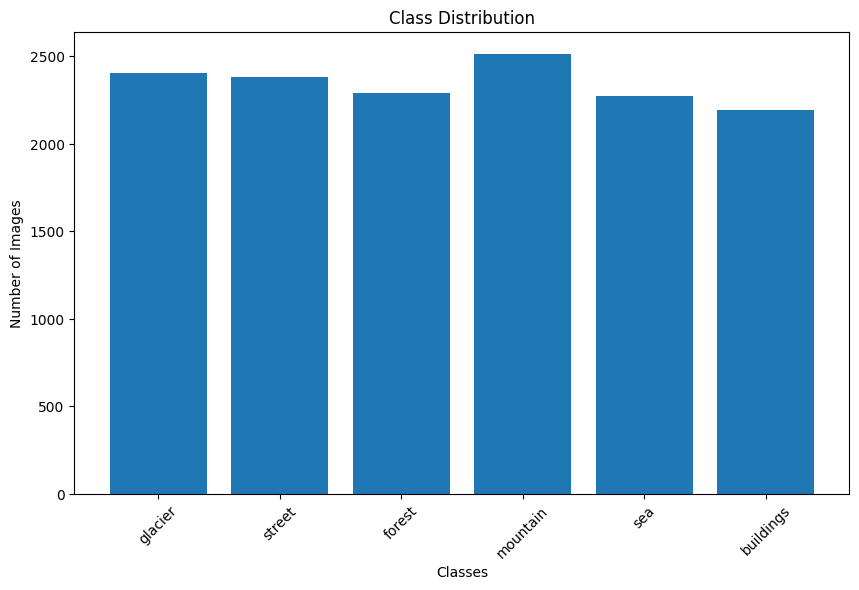

In [7]:
class_count = {}

for category in classes:
    folder = os.path.join(train_path, category)
    class_count[category] = len(os.listdir(folder))

plt.figure(figsize=(10,6))
plt.bar(class_count.keys(), class_count.values())
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

**Display Images**

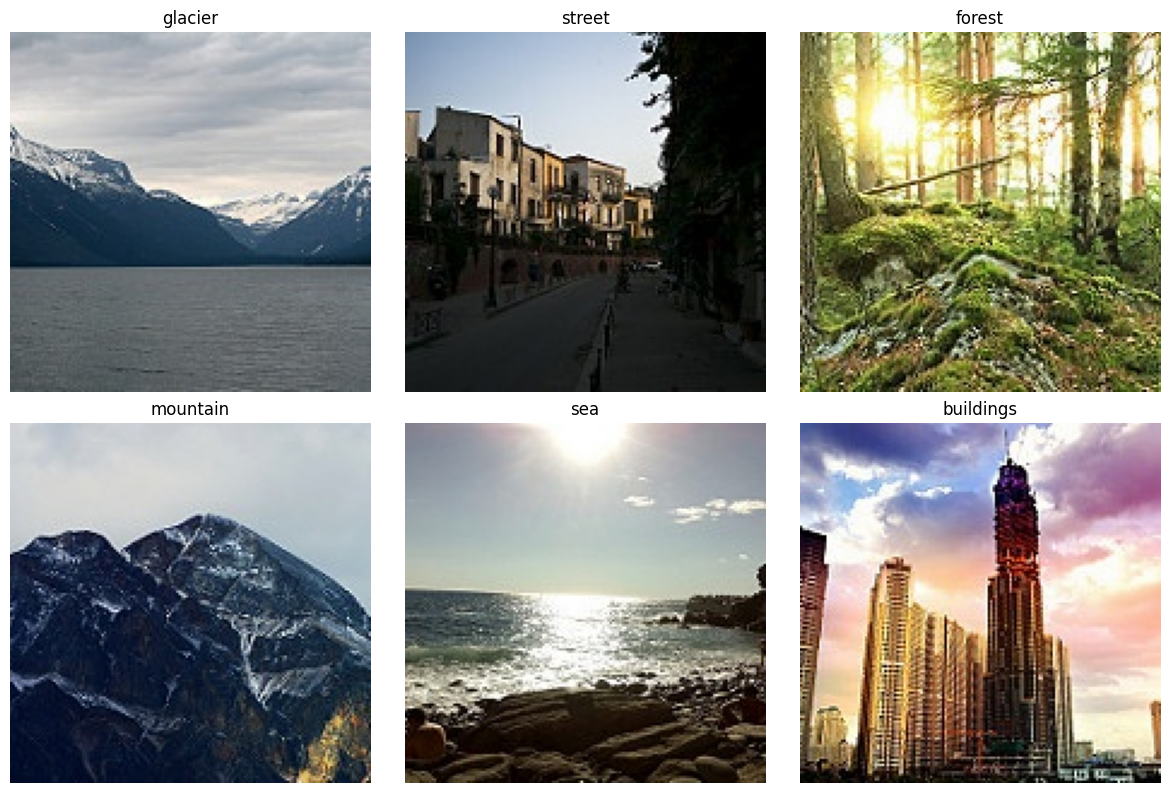

In [8]:
plt.figure(figsize=(12,8))

for i, category in enumerate(classes[:6]):
    folder = os.path.join(train_path, category)
    img_name = os.listdir(folder)[0]
    img_path = os.path.join(folder, img_name)

    img = plt.imread(img_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(category)
    plt.axis("off")

plt.tight_layout()
plt.show()

**Data Preprocessing and Augmentation**

In [9]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

**Train Generator**

In [10]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 11243 images belonging to 6 classes.


**Validation Generator**

In [11]:
validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 2807 images belonging to 6 classes.


**Test Generator**

In [12]:
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 3000 images belonging to 6 classes.


**Visualizing Augmented Images**

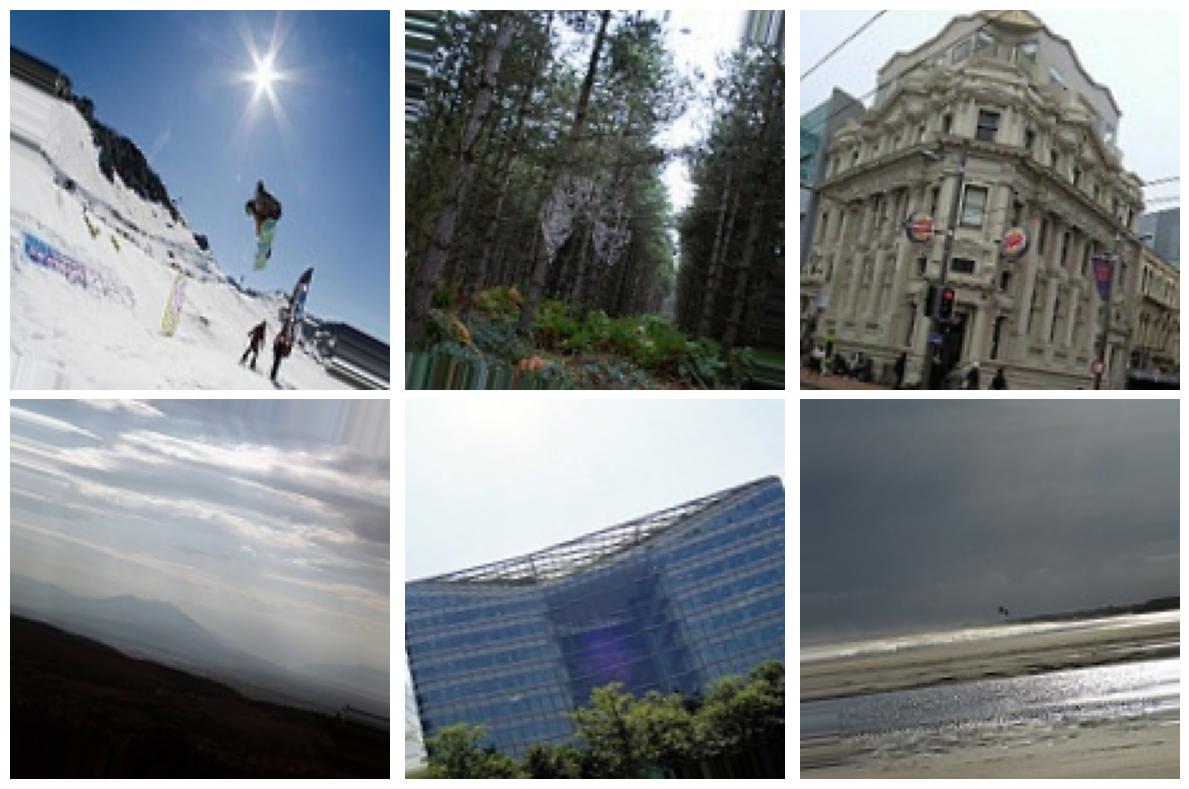

In [13]:
images, labels = next(train_generator)

plt.figure(figsize=(12,8))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

Part A  Baseline CNN Model

  Build Baseline CNN Model



In [14]:
baseline_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),

    Dense(6, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,838,886 (18.46 MB)

 Trainable params: 4,838,886 (18.46 MB)

 Non-trainable params: 0 (0.00 B)

Train Baseline Model

In [17]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_baseline = baseline_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 3450s 10s/step - accuracy: 0.6046 - loss: 1.0233 - val_accuracy: 0.6886 - val_loss: 0.8483
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 141s 400ms/step - accuracy: 0.7131 - loss: 0.7768 - val_accuracy: 0.7577 - val_loss: 0.6713
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 139s 395ms/step - accuracy: 0.7398 - loss: 0.6951 - val_accuracy: 0.7770 - val_loss: 0.6224
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 138s 393ms/step - accuracy: 0.7787 - loss: 0.6026 - val_accuracy: 0.7966 - val_loss: 0.5728
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 137s 389ms/step - accuracy: 0.7930 - loss: 0.5756 - val_accuracy: 0.8094 - val_loss: 0.5481
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 140s 396ms/step - accuracy: 0.8100 - loss: 0.5280 - val_accuracy: 0.7734 - val_loss: 0.6256
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 139s 395ms/step - accuracy: 0.8104 - loss: 0.5138 - val_accuracy: 0.7845 - val_loss: 0.5844
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 153s 435ms/step - accuracy: 0.8244 - 

Plot Training and Validation Accuracy

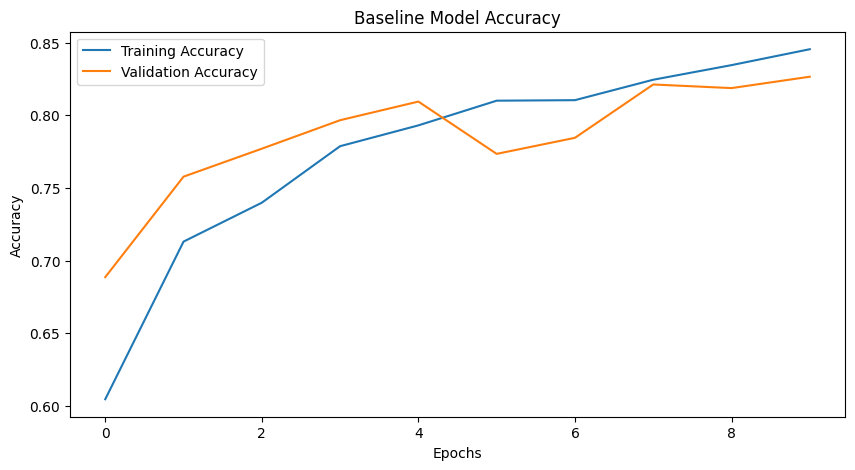

In [18]:
plt.figure(figsize=(10,5))

plt.plot(history_baseline.history['accuracy'], label='Training Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Validation Accuracy')

plt.title("Baseline Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Plot Training and Validation Loss

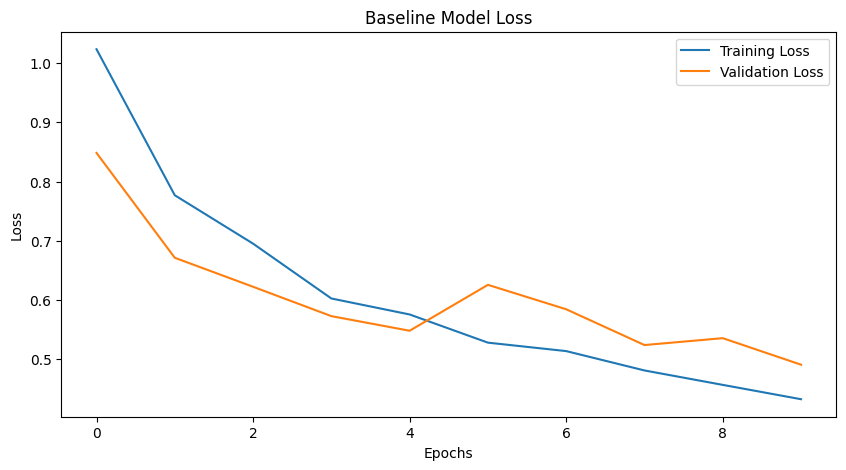

In [19]:
plt.figure(figsize=(10,5))

plt.plot(history_baseline.history['loss'], label='Training Loss')
plt.plot(history_baseline.history['val_loss'], label='Validation Loss')

plt.title("Baseline Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

Evaluate Baseline Model

In [20]:
test_loss, test_accuracy = baseline_model.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

94/94 ━━━━━━━━━━━━━━━━━━━━ 872s 9s/step - accuracy: 0.8433 - loss: 0.4602
Test Accuracy: 0.8433333039283752
Test Loss: 0.4601608216762543


Predictions

In [21]:
predictions = baseline_model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

print(predicted_classes[:10])

94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step
[0 0 0 5 0 3 0 5 0 0]


Classification Report

In [22]:
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))

              precision    recall  f1-score   support

   buildings       0.85      0.81      0.83       437
      forest       0.95      0.96      0.96       474
     glacier       0.79      0.83      0.81       553
    mountain       0.80      0.80      0.80       525
         sea       0.84      0.78      0.81       510
      street       0.84      0.90      0.87       501

    accuracy                           0.84      3000
   macro avg       0.85      0.84      0.84      3000
weighted avg       0.84      0.84      0.84      3000



Confusion Matrix

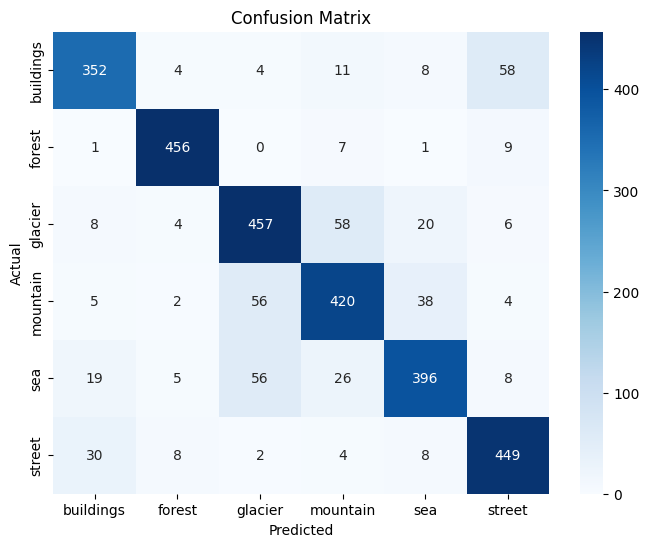

In [23]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Deeper CNN Model with Regularization

Build Deeper CNN Model

In [24]:
deeper_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(6, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile Deeper Model

In [25]:
deeper_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Model Summary

In [26]:
deeper_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 15, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     3,211,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,635,526 (13.87 MB)

 Trainable params: 3,634,566 (13.86 MB)

 Non-trainable params: 960 (3.75 KB)

Train Deeper Model

In [29]:
history_deeper = deeper_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 137s 389ms/step - accuracy: 0.5222 - loss: 1.2680 - val_accuracy: 0.5939 - val_loss: 1.0563
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 139s 394ms/step - accuracy: 0.6231 - loss: 0.9917 - val_accuracy: 0.6138 - val_loss: 1.0815
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 140s 399ms/step - accuracy: 0.6698 - loss: 0.9052 - val_accuracy: 0.7250 - val_loss: 0.8895


Plot Accuracy Graph

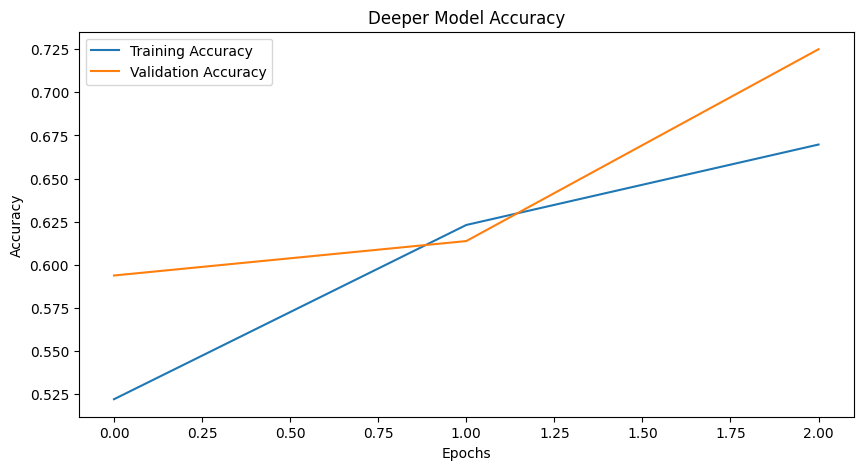

In [30]:
plt.figure(figsize=(10,5))

plt.plot(history_deeper.history['accuracy'], label='Training Accuracy')
plt.plot(history_deeper.history['val_accuracy'], label='Validation Accuracy')

plt.title("Deeper Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Plot Loss Graph

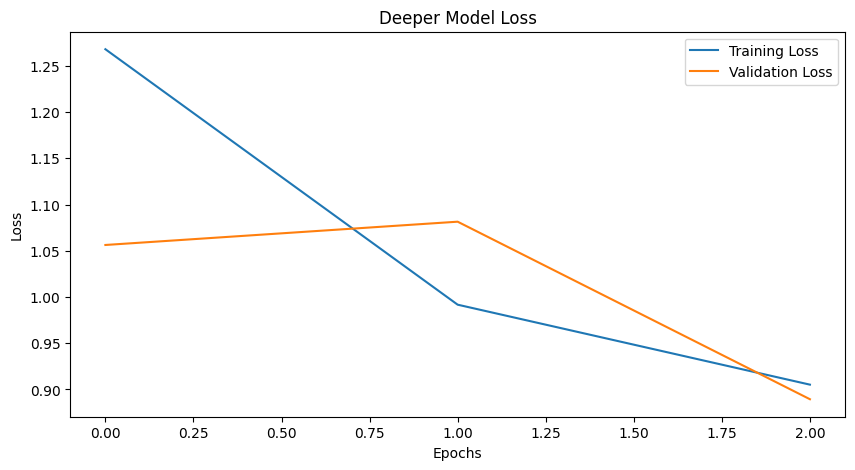

In [31]:
plt.figure(figsize=(10,5))

plt.plot(history_deeper.history['loss'], label='Training Loss')
plt.plot(history_deeper.history['val_loss'], label='Validation Loss')

plt.title("Deeper Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

Evaluate Deeper Model

In [32]:
test_loss, test_accuracy = deeper_model.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step - accuracy: 0.6240 - loss: 1.0206
Test Accuracy: 0.6240000128746033
Test Loss: 1.0205622911453247


Classification Report

In [33]:
predictions = deeper_model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))

94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 122ms/step
              precision    recall  f1-score   support

   buildings       0.70      0.59      0.64       437
      forest       0.61      0.98      0.75       474
     glacier       0.54      0.77      0.63       553
    mountain       0.66      0.54      0.59       525
         sea       0.62      0.42      0.50       510
      street       0.74      0.46      0.57       501

    accuracy                           0.62      3000
   macro avg       0.64      0.63      0.61      3000
weighted avg       0.64      0.62      0.61      3000



Experimentation and Comparative Analysis

Optimizer Comparison (SGD)

In [34]:
deeper_model.compile(
    optimizer=SGD(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = deeper_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5
)

Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 162s 446ms/step - accuracy: 0.6125 - loss: 0.9943 - val_accuracy: 0.6776 - val_loss: 0.9302
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 140s 398ms/step - accuracy: 0.6321 - loss: 0.9647 - val_accuracy: 0.5917 - val_loss: 1.0792
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 139s 394ms/step - accuracy: 0.6421 - loss: 0.9443 - val_accuracy: 0.6940 - val_loss: 0.9087
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 138s 393ms/step - accuracy: 0.6466 - loss: 0.9376 - val_accuracy: 0.7114 - val_loss: 0.8767
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 141s 402ms/step - accuracy: 0.6480 - loss: 0.9273 - val_accuracy: 0.6836 - val_loss: 0.9220


Optimizer Comparison (Adam)

In [35]:
deeper_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_adam = deeper_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5
)

Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 155s 413ms/step - accuracy: 0.6088 - loss: 1.0999 - val_accuracy: 0.5775 - val_loss: 1.0486
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 139s 394ms/step - accuracy: 0.6533 - loss: 0.9618 - val_accuracy: 0.5832 - val_loss: 1.1561
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 140s 398ms/step - accuracy: 0.6903 - loss: 0.8581 - val_accuracy: 0.5262 - val_loss: 1.2420
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 140s 399ms/step - accuracy: 0.7296 - loss: 0.7803 - val_accuracy: 0.6095 - val_loss: 0.9627
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 137s 390ms/step - accuracy: 0.7475 - loss: 0.7256 - val_accuracy: 0.7535 - val_loss: 0.7187


Ablation Study (Without Dropout)

In [36]:
ablation_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dense(128, activation='relu'),

    Dense(6, activation='softmax')
])

ablation_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

ablation_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 147s 406ms/step - accuracy: 0.6074 - loss: 1.0108 - val_accuracy: 0.6858 - val_loss: 0.8369
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 137s 389ms/step - accuracy: 0.7066 - loss: 0.7905 - val_accuracy: 0.7228 - val_loss: 0.7502
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 139s 394ms/step - accuracy: 0.7542 - loss: 0.6652 - val_accuracy: 0.7720 - val_loss: 0.6231
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 137s 391ms/step - accuracy: 0.7845 - loss: 0.5955 - val_accuracy: 0.7538 - val_loss: 0.6711
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 139s 394ms/step - accuracy: 0.8075 - loss: 0.5314 - val_accuracy: 0.7870 - val_loss: 0.5895


Part B — Transfer Learning

Load Pretrained Model (MobileNetV2)

In [37]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(150,150,3)
)

base_model.trainable = False

/tmp/ipykernel_714/1008031973.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Build Transfer Learning Model

In [38]:
transfer_model = Sequential([
    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(6, activation='softmax')
])

Compile Transfer Learning Model

In [39]:
transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Model Summary

In [40]:
transfer_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Train Transfer Learning Model

In [41]:
history_transfer = transfer_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 204s 513ms/step - accuracy: 0.8127 - loss: 0.5132 - val_accuracy: 0.8757 - val_loss: 0.3434
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 143s 407ms/step - accuracy: 0.8612 - loss: 0.3716 - val_accuracy: 0.8782 - val_loss: 0.3444
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 143s 406ms/step - accuracy: 0.8745 - loss: 0.3444 - val_accuracy: 0.8771 - val_loss: 0.3277
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 148s 421ms/step - accuracy: 0.8765 - loss: 0.3328 - val_accuracy: 0.8842 - val_loss: 0.3147
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 192s 392ms/step - accuracy: 0.8814 - loss: 0.3218 - val_accuracy: 0.8760 - val_loss: 0.3456
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 135s 383ms/step - accuracy: 0.8878 - loss: 0.3006 - val_accuracy: 0.8917 - val_loss: 0.2949
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 134s 382ms/step - accuracy: 0.8913 - loss: 0.2958 - val_accuracy: 0.8935 - val_loss: 0.2911
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 136s 386ms/step - accuracy: 0.8894 -

Plot Accuracy Graph

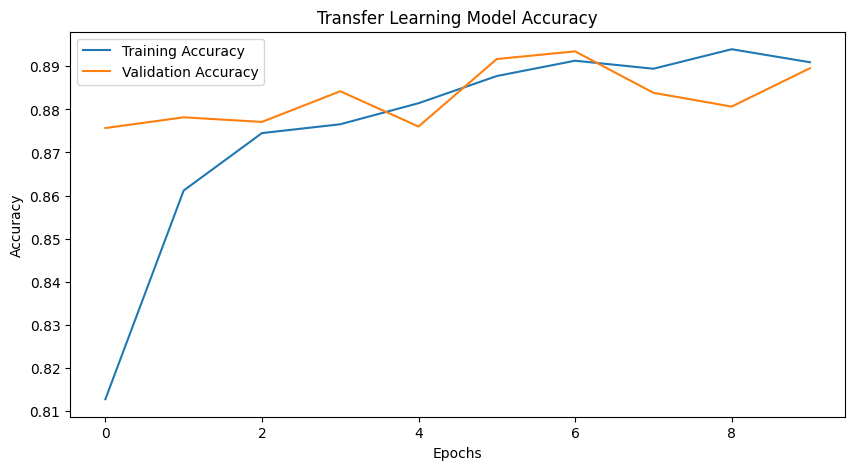

In [42]:
plt.figure(figsize=(10,5))

plt.plot(history_transfer.history['accuracy'], label='Training Accuracy')
plt.plot(history_transfer.history['val_accuracy'], label='Validation Accuracy')

plt.title("Transfer Learning Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Plot Loss Graph

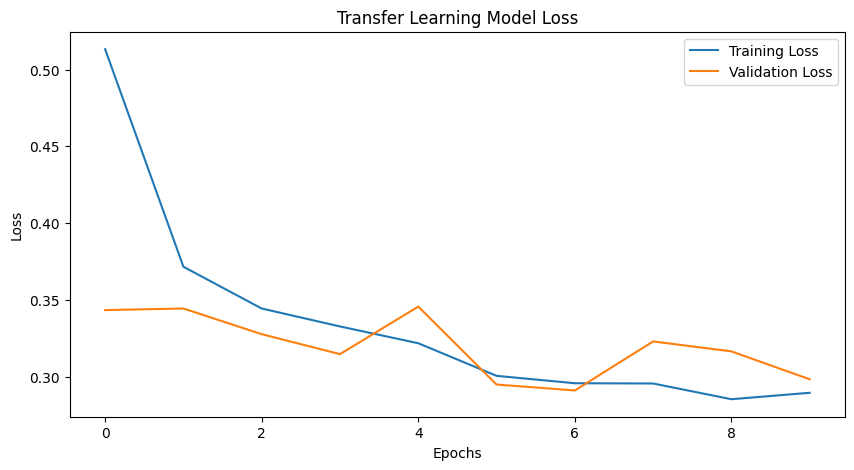

In [43]:
plt.figure(figsize=(10,5))

plt.plot(history_transfer.history['loss'], label='Training Loss')
plt.plot(history_transfer.history['val_loss'], label='Validation Loss')

plt.title("Transfer Learning Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

valuate Transfer Learning Model

In [44]:
test_loss, test_accuracy = transfer_model.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

94/94 ━━━━━━━━━━━━━━━━━━━━ 23s 249ms/step - accuracy: 0.9053 - loss: 0.2657
Test Accuracy: 0.9053333401679993
Test Loss: 0.2656538188457489


Classification Report

In [45]:
predictions = transfer_model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
))

94/94 ━━━━━━━━━━━━━━━━━━━━ 22s 188ms/step
              precision    recall  f1-score   support

   buildings       0.90      0.92      0.91       437
      forest       0.97      0.99      0.98       474
     glacier       0.87      0.84      0.85       553
    mountain       0.84      0.85      0.85       525
         sea       0.94      0.93      0.94       510
      street       0.92      0.91      0.91       501

    accuracy                           0.91      3000
   macro avg       0.91      0.91      0.91      3000
weighted avg       0.91      0.91      0.91      3000



Final Comparison

In [46]:
print("Compare:")
print("1. Baseline CNN")
print("2. Deeper CNN")
print("3. Transfer Learning Model")

print("Transfer Learning usually gives best accuracy and faster convergence.")

Compare:
1. Baseline CNN
2. Deeper CNN
3. Transfer Learning Model
Transfer Learning usually gives best accuracy and faster convergence.
